# 260414 ETF 금융 데이터 수집 & 전처리

**6주차 Day 1** | 두 번째 프로젝트: 금융 ETF 챗봇 만들기

이번 주(w6)는 1~5주차에서 배운 RAG 전체를 **금융 데이터**에 적용하는 주간이다.  
오늘은 데이터 **수집 -> 스키마 설계 -> 전처리(결측치/이상치)** 파이프라인을 만든다.

| 단계 | 내용 |
|------|------|
| 1 | 더미 데이터로 matplotlib 시각화 연습 |
| 2 | `@dataclass`로 ETF 데이터 스키마 설계 |
| 3 | FinanceDataReader로 실제 ETF 가격 수집 |
| 4 | 결측치 처리 (ffill, interpolation, rolling) |
| 5 | 이상치 탐지 (IQR, Z-score) |
| 6 | 피처 엔지니어링 & 전처리 파이프라인 |

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rmaomina/llm_service_modu6/blob/main/Colab%20Notebooks/w6_finance_rag/llm_260414_portfolio_analysis.ipynb)

---
## 0. 환경 설정

In [1]:
!pip install -q finance-datareader langchain langchain-community langchain-core langchain-openai matplotlib numpy openai pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
# --- Colab 전용 ---
import os
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

from openai import OpenAI
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
import json
import random

client = OpenAI()
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')

In [3]:
import os, json, math
from datetime import datetime, timedelta
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
# load_dotenv()

# 한글 폰트 설정 (Colab: 'NanumGothic' 설치 필요, Mac: 'AppleGothic')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")

---
## 1. 더미 데이터 시각화

matplotlib의 핵심 패턴:  
- `fig, ax = plt.subplots()` -> ax 위에 그린다 (도화지 + 붓 비유)  
- `subplots(1, 2)` -> 한 줄에 그래프 2개 (ax1, ax2)

In [4]:
# 카테고리별 ETF 종목 수 (더미 데이터)
categories = {
    "국내주식": 145, "해외주식": 120, "채권": 85,
    "섹터": 95, "원자재": 25, "부동산": 15, "기타": 30,
}

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

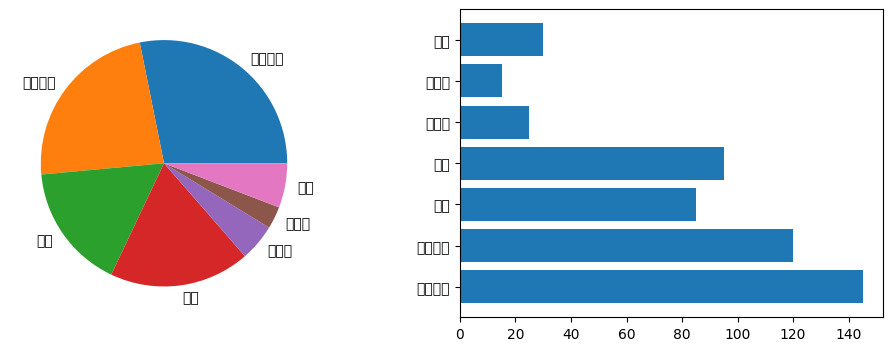

In [5]:
# pie chart + 가로 막대 그래프를 나란히
# subplots(1,2) = 1행 2열 -> ax1(파이), ax2(막대)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.pie(categories.values(), labels=categories.keys())  # 파이 차트
ax2.barh(list(categories.keys()), list(categories.values()))  # barh = 가로 막대 (horizontal)

plt.show()

### 산점도 (Scatter Plot): 리스크 vs 수익률

산점도는 x축(리스크)과 y축(수익률)에 점을 찍어서 ETF 간 비교를 한눈에 보는 그래프이다.  
비유: 학생들을 "공부 시간(x) vs 성적(y)" 좌표에 찍는 것과 같다.

In [6]:
# ETF 더미 데이터: 이름, 카테고리, 1년 수익률, 리스크
etf_universe = [
    {"name": "KODEX 200", "cat": "국내주식", "ret_1y": 12.3, "risk": 15.2},
    {"name": "TIGER S&P500", "cat": "해외주식", "ret_1y": 18.5, "risk": 13.8},
    {"name": "KODEX 배당가치", "cat": "배당", "ret_1y": 8.2, "risk": 10.5},
    {"name": "TIGER 반도체", "cat": "섹터", "ret_1y": 35.2, "risk": 28.4},
    {"name": "KODEX 국고채3년", "cat": "채권", "ret_1y": 3.5, "risk": 2.1},
    {"name": "KODEX 골드선물", "cat": "원자재", "ret_1y": 15.8, "risk": 16.3},
    {"name": "KODEX 2차전지", "cat": "섹터", "ret_1y": -5.2, "risk": 32.1},
    {"name": "TIGER 단기통안채", "cat": "채권", "ret_1y": 3.2, "risk": 0.8},
]

In [7]:
df_etf = pd.DataFrame(etf_universe)
df_etf

,name,cat,ret_1y,risk
0,KODEX 200,국내주식,12.3,15.2
1,TIGER S&P500,해외주식,18.5,13.8
2,KODEX 배당가치,배당,8.2,10.5
3,TIGER 반도체,섹터,35.2,28.4
4,KODEX 국고채3년,채권,3.5,2.1
5,KODEX 골드선물,원자재,15.8,16.3
6,KODEX 2차전지,섹터,-5.2,32.1
7,TIGER 단기통안채,채권,3.2,0.8


In [8]:
# unique(): 중복 제거 -> 카테고리별로 색을 다르게 찍기 위해
df_etf['cat'].unique()

array(['국내주식', '해외주식', '배당', '섹터', '채권', '원자재'], dtype=object)

In [9]:
# 카테고리 필터링 예시: df[df['col'] == '값'] -> True인 행만 가져온다
# 비유: 엑셀에서 필터 거는 것과 같음
for _, row in df_etf[df_etf['cat']=='채권'].iterrows():
    print(row)

name      KODEX 국고채3년
cat                채권
ret_1y            3.5
risk              2.1
Name: 4, dtype: object
name      TIGER 단기통안채
cat                채권
ret_1y            3.2
risk              0.8
Name: 7, dtype: object


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

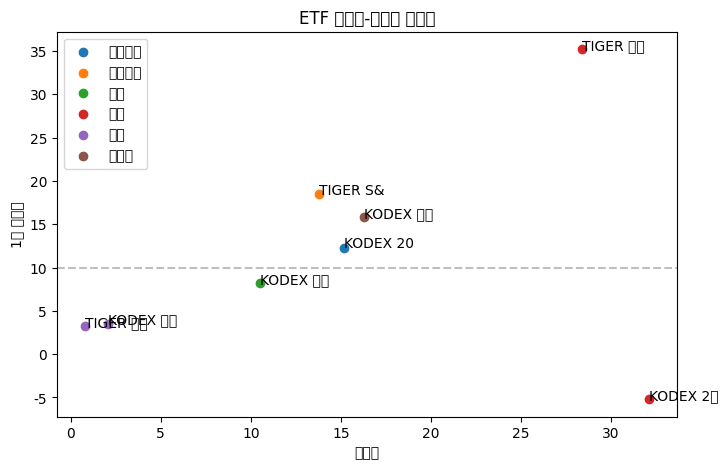

In [10]:
# 카테고리별 색 다르게 scatter plot 그리기
fig, ax = plt.subplots(figsize=(8, 5))
for cat in df_etf['cat'].unique():
    sub = df_etf[df_etf['cat'] == cat]  # 해당 카테고리만 필터
    ax.scatter(sub['risk'], sub['ret_1y'], label=cat)
    for _, row in sub.iterrows():
        ax.annotate(row['name'][:8], (row['risk'], row['ret_1y']))  # 점 옆에 이름 표시

ax.set_xlabel('리스크')
ax.set_ylabel('1년 수익률')
ax.set_title('ETF 리스크-수익률 산점도')
ax.axhline(y=10, color='gray', linestyle='--', alpha=0.5)  # 수익률 10% 기준선
ax.legend()
plt.show()

---
## 2. 데이터 스키마 설계 (`@dataclass`)

`@dataclass`는 데이터 구조에 **규칙(타입, 검증)을 강제**하는 파이썬 장치이다.  
비유: 엑셀 셀에 "숫자만 입력 가능" 유효성 검사를 거는 것과 같다.  
- `__init__`을 자동 생성해줌 -> 직접 안 써도 됨
- `__post_init__`에서 값 검증 로직 추가 가능

In [11]:
@dataclass
class ETFSchema:
    """ETF 기본 정보 스키마 - 데이터 타입과 유효성을 강제한다"""
    ticker: str           # 종목코드 (예: '069500')
    name: str             # 종목명
    category: str         # 카테고리
    expense_ratio: float  # 수수료율
    risk_level: str = "중간"        # 디폴트값 지정 가능
    aum_billion: float = 0.0       # 운용자산(억)
    description: str = ""
    keywords: List[str] = field(default_factory=list)  # 리스트는 field() 사용

    def __post_init__(self):
        """생성 직후 자동 호출 -> 유효성 검증"""
        # 수수료는 0~5% 범위만 허용
        if self.expense_ratio < 0 or self.expense_ratio > 5:
            raise ValueError(f"수수료 범위 오류: {self.expense_ratio}")
        # 리스크 등급은 정해진 값만 허용 ("매우 낮음" 처럼 띄어쓰기 넣으면 에러!)
        valid_risks = ["매우낮음", "낮음", "중간", "높음", "매우높음"]
        if self.risk_level not in valid_risks:
            raise ValueError(f"리스크 등급 오류: {self.risk_level}")

In [12]:
# 스키마로 ETF 객체 생성
etf = ETFSchema(
    ticker="069500", name="KODEX 200", category="국내주식",
    expense_ratio=1.5, keywords=['코스피', '대형주', '인덱스']
)
etf

ETFSchema(ticker='069500', name='KODEX 200', category='국내주식', expense_ratio=1.5, risk_level='중간', aum_billion=0.0, description='', keywords=['코스피', '대형주', '인덱스'])

In [13]:
# 개별 필드 접근
etf.ticker, etf.name, etf.expense_ratio

('069500', 'KODEX 200', 1.5)

### dataclass <-> dict <-> JSON 변환

RAG에서 context로 넘기거나 파일 저장할 때 dict/JSON 변환이 필수이다.  
비유: 택배 보낼 때 물건(dataclass)을 박스(dict)에 넣고 송장(JSON)을 붙이는 것.

In [14]:
# dataclass -> dict
etf_dict = asdict(etf)
etf_dict

{'ticker': '069500',
 'name': 'KODEX 200',
 'category': '국내주식',
 'expense_ratio': 1.5,
 'risk_level': '중간',
 'aum_billion': 0.0,
 'description': '',
 'keywords': ['코스피', '대형주', '인덱스']}

In [15]:
# dict -> JSON 문자열 (ensure_ascii=False: 한글 깨짐 방지)
etf_json = json.dumps(etf_dict, ensure_ascii=False, indent=2)
print(etf_json)

{
  "ticker": "069500",
  "name": "KODEX 200",
  "category": "국내주식",
  "expense_ratio": 1.5,
  "risk_level": "중간",
  "aum_billion": 0.0,
  "description": "",
  "keywords": [
    "코스피",
    "대형주",
    "인덱스"
  ]
}


In [16]:
# JSON -> dataclass 복원: **로 dict를 풀어서 넣어준다
# json.loads() = JSON 문자열 -> dict
# ** = dict의 key-value를 함수 인자로 풀어줌
ETFSchema(**json.loads(etf_json))

ETFSchema(ticker='069500', name='KODEX 200', category='국내주식', expense_ratio=1.5, risk_level='중간', aum_billion=0.0, description='', keywords=['코스피', '대형주', '인덱스'])

### 유효성 검증 테스트

`__post_init__`이 자동으로 값을 체크해서, 잘못된 데이터가 들어오면 즉시 에러를 낸다.

In [17]:
# 테스트 케이스: 정상 / 수수료 범위 오류 / 리스크 등급 오류
test_cases = [
    {"ticker": "A", "name": "정상", "category": "채권",
     "expense_ratio": 0.05, "risk_level": "낮음"},
    {"ticker": "B", "name": "수수료오류", "category": "주식",
     "expense_ratio": -0.5, "risk_level": "중간"},
    {"ticker": "C", "name": "리스크오류", "category": "원자재",
     "expense_ratio": 0.3, "risk_level": "최고"},  # "최고"는 valid_risks에 없음!
]

for tc in test_cases:
    try:
        e = ETFSchema(**tc)
        print(f" {tc['name']}: 생성 성공")
    except ValueError as err:
        print(f" {tc['name']}: {err}")

 정상: 생성 성공
 수수료오류: 수수료 범위 오류: -0.5
 리스크오류: 리스크 등급 오류: 최고


### 실습: ETFReturns 스키마 만들기

수익률 데이터 스키마를 만들고, `__post_init__`에서 수익률 범위(-100% ~ 500%)를 검증한다.  
`getattr(self, field_name)` = `self.field_name`과 같은데, 변수명을 문자열로 쓸 수 있다.

In [18]:
@dataclass
class ETFReturns:
    """ETF 수익률 스키마 - 기간별 수익률 + 유효성 검증"""
    ticker: str
    return_1m: float   # 1개월 수익률
    return_3m: float   # 3개월 수익률
    return_1y: float   # 1년 수익률
    return_3y: float   # 3년 수익률

    def __post_init__(self):
        # 모든 수익률 필드를 for문으로 검증 (하나하나 if문 쓰면 코드 길어짐)
        # getattr(self, 'return_1m') == self.return_1m
        for field_name in ['return_1m', 'return_3m', 'return_1y', 'return_3y']:
            value = getattr(self, field_name)
            if value < -100 or value > 500:
                raise ValueError(f"{field_name} 오류: {value}")

In [19]:
# 정상 케이스
ETFReturns("069500", 4.5, 6.4, 12.3, 28.5)

ETFReturns(ticker='069500', return_1m=4.5, return_3m=6.4, return_1y=12.3, return_3y=28.5)

In [20]:
# 오류 케이스: return_1m이 -200.1 -> 범위 초과
try:
    ETFReturns("123456", -200.1, 5.4, 12.3, 28.5)
except ValueError as e:
    print(f"검증 실패: {e}")

검증 실패: return_1m 오류: -200.1


---
## 3. 실제 ETF 데이터 수집 (FinanceDataReader)

`FinanceDataReader`는 한국 주식/ETF 가격을 가져오는 라이브러리이다.  
핵심 함수 2개만 알면 됨:
- `fdr.StockListing('ETF/KR')` -> 한국 ETF 전체 목록
- `fdr.DataReader(ticker, start, end)` -> 특정 종목의 일별 가격

In [21]:
import FinanceDataReader as fdr

In [22]:
# 한국 ETF 전체 목록 가져오기
etf_list = fdr.StockListing('ETF/KR')
print(f"총 ETF 수: {len(etf_list)}")
etf_list.head(3)

총 ETF 수: 1093


,Symbol,Category,Name,Price,RiseFall,Change,ChangeRate,NAV,EarningRate,Volume,Amount,MarCap
0,069500,1,KODEX 200,94050,5,-660,-0.70,94029.0,33.0631,10221423,962685,213541
1,360750,4,TIGER 미국S&P500,25940,2,160,0.62,25977.0,1.9731,11532078,298601,161023
2,396500,2,TIGER 반도체TOP10,35735,5,-200,-0.56,35759.0,48.2780,8942100,319898,95198


In [23]:
# 특정 종목 1년치 가격 데이터 가져오기
ticker = "069500"  # KODEX 200
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')

print(f"기간: {start_date} ~ {end_date}")
price_df = fdr.DataReader(ticker, start_date, end_date)
print(f"데이터 수: {len(price_df)}건 (주말/휴일 제외)")
price_df.head()

기간: 2025-04-19 ~ 2026-04-19
데이터 수: 242건 (주말/휴일 제외)


,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-21,32727,32918,32634,32766,5020620,0.001345
2025-04-22,32604,32824,32594,32658,5779669,-0.003296
2025-04-23,33203,33291,33037,33247,6821321,0.018035
2025-04-24,33252,33295,32977,33188,6869882,-0.001775
2025-04-25,33550,33653,33383,33496,5908528,0.009280


In [24]:
# 재사용 가능한 함수로 묶기
# 비유: 매번 주소 치고 택배 보내는 대신, 자동 발송 버튼을 만드는 것
def collect_etf_price(ticker, days=365):
    """ETF 가격 데이터를 수집하는 함수"""
    end_date = datetime.now().strftime('%Y-%m-%d')
    start_date = (datetime.now() - timedelta(days=days)).strftime('%Y-%m-%d')

    try:
        df = fdr.DataReader(ticker, start_date, end_date)
        if len(df) > 0:
            return {'status': 'real', 'data': df, 'ticker': ticker}
    except Exception:
        pass  # API 오류 시 None 반환

result = collect_etf_price('069500')
print(f"상태: {result['status']}, 데이터: {len(result['data'])}건")

상태: real, 데이터: 242건


---
## 4. 결측치 처리

금융 데이터에서 결측치가 생기는 이유:  
- 주말/공휴일 -> row 전체가 없음  
- 데이터 오류 -> row 일부만 NaN  

처리 방법 3가지:

| 방법 | 설명 | 비유 |
|------|------|------|
| **ffill** (Forward Fill) | 이전 날의 값으로 채움 | 어제 온도를 오늘 온도로 쓰는 것 |
| **interpolation** | 앞뒤 값의 중간값으로 채움 | 두 점 사이에 자로 선 긋는 것 |
| **rolling mean** | 최근 N일 평균으로 채움 | 최근 일주일 평균 온도로 채우는 것 |

In [25]:
# 결측치 실습을 위해 5% 랜덤으로 NaN 만들기
sample_df = price_df.copy()
mask = np.random.random(len(sample_df)) < 0.05  # 5% 확률로 True
sample_df.loc[mask, 'Close'] = np.nan
print(f"결측치 수: {sample_df['Close'].isna().sum()}개 / 전체 {len(sample_df)}개")

결측치 수: 7개 / 전체 242개


In [26]:
# 방법 1: Forward Fill - 이전 값으로 채우기
ffill_df = sample_df.copy()
ffill_df['Close'] = ffill_df['Close'].ffill()
print(f"ffill 후 결측치: {ffill_df['Close'].isna().sum()}개")

ffill 후 결측치: 0개


In [27]:
# 방법 2: Linear Interpolation - 앞뒤 값 사이를 선형으로 보간
interp_df = sample_df.copy()
interp_df['Close'] = interp_df['Close'].interpolate(method='linear')
print(f"interpolation 후 결측치: {interp_df['Close'].isna().sum()}개")

interpolation 후 결측치: 0개


In [28]:
# 방법 3: Rolling Mean - 최근 5일 이동평균으로 채우기
rolling_df = sample_df.copy()
rolling_mean = rolling_df['Close'].rolling(5, min_periods=1).mean()
rolling_df['Close'] = rolling_df['Close'].fillna(rolling_mean)
print(f"rolling 후 결측치: {rolling_df['Close'].isna().sum()}개")

rolling 후 결측치: 0개


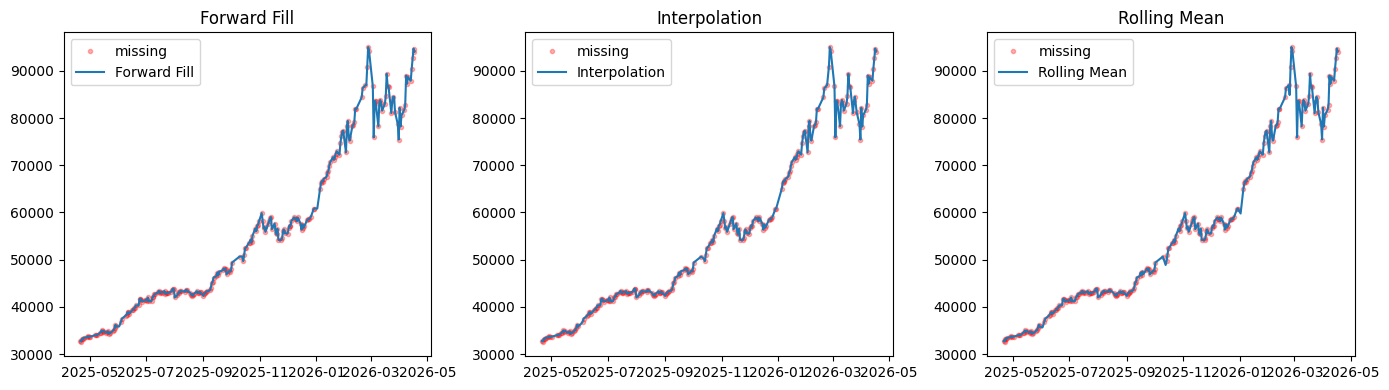

In [29]:
# 3가지 방법 시각적 비교
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, df_filled, title in zip(
    axes,
    [ffill_df, interp_df, rolling_df],
    ['Forward Fill', 'Interpolation', 'Rolling Mean']
):
    ax.plot(sample_df.index, sample_df['Close'], 'ro', markersize=3, alpha=0.3, label='missing')
    ax.plot(df_filled.index, df_filled['Close'], label=title)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

---
## 5. 이상치 탐지 (Outlier Detection)

이상치 = 정상 범위를 벗어나는 비정상적인 값  
비유: 시험 평균 70점인데 혼자 300점 받은 학생 -> 뭔가 이상하다!

| 방법 | 원리 | 기준 |
|------|------|------|
| **IQR** | 중앙 50% 범위(Q1~Q3)에서 1.5배 벗어나면 이상치 | Q1 - 1.5*IQR ~ Q3 + 1.5*IQR |
| **Z-score** | 평균에서 표준편차 몇 배 떨어졌는지 | \|z\| > 3 이면 이상치 |

In [30]:
def detect_iqr(series, factor=1.5):
    """IQR 방식: 중앙값 기준으로 박스 범위 밖이면 이상치"""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - factor * iqr) | (series > q3 + factor * iqr)

def detect_z(series, threshold=3.0):
    """Z-score 방식: (값 - 평균) / 표준편차 가 3 넘으면 이상치"""
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

# 두 방법으로 이상치 탐지
z_outliers = detect_z(ffill_df)
iqr_outliers = detect_iqr(ffill_df)

print("Z-score 이상치 수:")
print(z_outliers.sum())
print("\nIQR 이상치 수:")
print(iqr_outliers.sum())

Z-score 이상치 수:
Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64

IQR 이상치 수:
Open       0
High       0
Low        0
Close      0
Volume    10
Change    22
dtype: int64


In [31]:
# 두 방법 모두에서 이상치로 탐지된 것 (교집합)
print("두 방법 교집합:")
print((z_outliers & iqr_outliers).sum())

두 방법 교집합:
Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64


---
## 6. 피처 엔지니어링 & 전처리 파이프라인

원본 Close 가격에서 분석에 유용한 피처를 추가로 만든다:
- **return** (수익률): 어제 대비 오늘 얼마나 변했는지 (%) -> `pct_change()`
- **log_return** (로그 수익률): 금융에서 선호하는 수익률 계산 방식 (정규분포에 더 가까움)
- **vol_5d / vol_20d** (변동성): 최근 5일/20일 수익률의 표준편차 -> 위험도 지표

In [32]:
# Close 가격에서 피처 만들기
features = ffill_df[['Close']].copy()

# pct_change(): (오늘 - 어제) / 어제 = 일별 수익률
features['return'] = features['Close'].pct_change()

# log(오늘/어제): 로그 수익률 (연속 복리 개념)
features['log_return'] = np.log(features['Close'] / features['Close'].shift(1))

features.head()

,Close,return,log_return
Date,,,
2025-04-21,32766.0,NaN,NaN
2025-04-22,32658.0,-0.003296,-0.003302
2025-04-23,33247.0,0.018035,0.017875
2025-04-24,33188.0,-0.001775,-0.001776
2025-04-25,33496.0,0.009280,0.009238


In [33]:
# 변동성: rolling(N).std() = 최근 N일 수익률의 표준편차
# 비유: 최근 5일 동안 가격이 얼마나 출렁였는지의 척도
features['vol_5d'] = features['return'].rolling(5).std()
features['vol_20d'] = features['return'].rolling(20).std()

features.dropna().head()

,Close,return,log_return,vol_5d,vol_20d
Date,,,,,
2025-05-22,34349.0,-0.012875,-0.012958,0.008954,0.008032
2025-05-23,34379.0,0.000873,0.000873,0.008550,0.007930
2025-05-26,34926.0,0.015911,0.015786,0.010414,0.007723
2025-05-27,35036.0,0.003150,0.003145,0.010414,0.007658
2025-05-28,35512.0,0.013586,0.013495,0.011499,0.007908


### 전처리 파이프라인 함수

지금까지 한 것(결측치 -> 이상치 -> 피처)을 하나의 함수로 묶는다.  
비유: 세탁기에 넣으면 세탁->헹굼->탈수가 자동으로 되는 것처럼.

In [34]:
def preprocess_pipeline(df):
    """ETF 가격 데이터 전처리 파이프라인
    1단계: 결측값 처리 (interpolation + ffill/bfill)
    2단계: 이상치 제거 (IQR * 1.5 범위 밖 -> ffill)
    3단계: 피처 추가 (수익률, 로그 수익률)
    """
    result = df[['Close']].copy()

    # 1. 결측값 처리 (linear interpolation -> 나머지는 ffill/bfill)
    result['Close'] = result['Close'].interpolate(method='linear')
    result['Close'] = result['Close'].ffill().bfill()

    # 2. 이상치를 NaN으로 바꾼 후 ffill (IQR * 1.5)
    ret = result['Close']
    q1, q3 = ret.quantile(0.25), ret.quantile(0.75)
    iqr = q3 - q1
    outlier_mask = (ret < q1 - 1.5 * iqr) | (ret > q3 + 1.5 * iqr)
    result.loc[outlier_mask, 'Close'] = np.nan
    result['Close'] = result['Close'].ffill()

    # 3. 피처 추가
    result['return'] = result['Close'].pct_change()
    result['log_return'] = np.log(result['Close'] / result['Close'].shift(1))

    return result

In [35]:
# 파이프라인 실행
processed = preprocess_pipeline(price_df)
processed.head()

,Close,return,log_return
Date,,,
2025-04-21,32766.0,NaN,NaN
2025-04-22,32658.0,-0.003296,-0.003302
2025-04-23,33247.0,0.018035,0.017875
2025-04-24,33188.0,-0.001775,-0.001776
2025-04-25,33496.0,0.009280,0.009238


---
## 7. 다음 시간 예고

오늘 수집+전처리한 금융 데이터를 가지고:  
- **이동평균** (SMA/EMA): 노이즈를 줄여서 추세를 보는 방법
- **트렌드 분해** (Decomposition): 시계열 = 트렌드 + 계절성 + 잔차  
  - 비유: 에어컨 매출 = 매년 성장(트렌드) + 여름에 잘 팔림(계절성) + 나머지(잔차)
- **이상 탐지**: 시계열 데이터에서 anomaly detection

이번 주 전체 흐름: 데이터 수집(오늘) -> 분석(내일) -> RAG 적용 + 평가(모레)